IMPORTING LIBRARY


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


## LOADING CSV FILE

In [3]:
# Load the CSV file
file_path = 'POWER_Point_Climatology_Climatology_2001_2020_010d54N_000d40W_LST.csv'
df = pd.read_csv(file_path, skiprows=21)  # Skip the header rows

print("Original data loaded:")
print(f"Shape: {df.shape}")
df.head()


Original data loaded:
Shape: (10, 14)


,PARAMETER,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,ALLSKY_SFC_SW_DIFF,2.4156,2.8030,2.8392,2.8205,2.7449,2.6760,2.5435,2.5044,2.4876,2.5138,2.1466,2.0534,2.5442
1,ALLSKY_SFC_SW_DNI,4.1611,3.5762,3.3336,3.4097,3.4970,2.9729,2.5334,2.2202,2.7110,3.7692,4.8194,4.9262,3.4934
2,ALLSKY_SFC_SW_DWN,5.4814,5.6906,5.8510,5.9878,5.9090,5.4737,5.0254,4.7940,5.0971,5.6762,5.6326,5.4461,5.5034
3,CLRSKY_SFC_SW_DWN,5.6755,5.9626,6.3634,6.7946,6.9096,6.7418,6.8582,6.9905,6.8304,6.3953,5.8961,5.5901,6.4190
4,PS,98.8500,98.6800,98.5800,98.5700,98.7200,98.8900,98.9400,98.9100,98.9000,98.8100,98.7700,98.8500,98.7900


## DATA PREPROCESSING

In [5]:
# Check the structure of the data
print("Data structure before processing:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Set PARAMETER as index and transpose
df_processed = df.set_index('PARAMETER').T

# Remove the 'ANN' row (annual averages)
df_processed = df_processed.drop('ANN', errors='ignore')

# Convert index to months (numeric)
df_processed.index = pd.to_datetime(df_processed.index, format='%b').month

# Convert all values to numeric
df_processed = df_processed.apply(pd.to_numeric)

print("\nProcessed data shape:", df_processed.shape)
print("Processed data index:", df_processed.index.tolist())
print("\nProcessed data columns:")
print(df_processed.columns.tolist())
df_processed.head()


Data structure before processing:
['PARAMETER', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']

First few rows:
            PARAMETER      JAN      FEB      MAR      APR      MAY      JUN  \
0  ALLSKY_SFC_SW_DIFF   2.4156   2.8030   2.8392   2.8205   2.7449   2.6760   
1   ALLSKY_SFC_SW_DNI   4.1611   3.5762   3.3336   3.4097   3.4970   2.9729   
2   ALLSKY_SFC_SW_DWN   5.4814   5.6906   5.8510   5.9878   5.9090   5.4737   
3   CLRSKY_SFC_SW_DWN   5.6755   5.9626   6.3634   6.7946   6.9096   6.7418   
4                  PS  98.8500  98.6800  98.5800  98.5700  98.7200  98.8900   

       JUL      AUG      SEP      OCT      NOV      DEC      ANN  
0   2.5435   2.5044   2.4876   2.5138   2.1466   2.0534   2.5442  
1   2.5334   2.2202   2.7110   3.7692   4.8194   4.9262   3.4934  
2   5.0254   4.7940   5.0971   5.6762   5.6326   5.4461   5.5034  
3   6.8582   6.9905   6.8304   6.3953   5.8961   5.5901   6.4190  
4  98.9400  98.9100  98.9000  98.8

PARAMETER,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PS,PSC,QV2M,T2M,WS2M,WSC
1,2.4156,4.1611,5.4814,5.6755,98.85,92.36,6.11,24.39,2.87,3.00
2,2.8030,3.5762,5.6906,5.9626,98.68,92.27,7.28,28.04,2.72,2.71
3,2.8392,3.3336,5.8510,6.3634,98.58,92.24,10.95,31.04,2.36,2.21
4,2.8205,3.4097,5.9878,6.7946,98.57,92.23,15.34,31.02,2.57,2.29
5,2.7449,3.4970,5.9090,6.9096,98.72,92.34,17.14,29.40,2.42,2.29


## DATA EXPLORATION

In [6]:
# Basic statistics
print("Basic Statistics:")
df_processed.describe()


# Check data types and info
print("Data Info:")
df_processed.info()


# Display the full processed dataset
print("Full Processed Dataset:")
df_processed


Basic Statistics:
Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 1 to 12
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ALLSKY_SFC_SW_DIFF  12 non-null     float64
 1   ALLSKY_SFC_SW_DNI   12 non-null     float64
 2   ALLSKY_SFC_SW_DWN   12 non-null     float64
 3   CLRSKY_SFC_SW_DWN   12 non-null     float64
 4   PS                  12 non-null     float64
 5   PSC                 12 non-null     float64
 6   QV2M                12 non-null     float64
 7   T2M                 12 non-null     float64
 8   WS2M                12 non-null     float64
 9   WSC                 12 non-null     float64
dtypes: float64(10)
memory usage: 1008.0 bytes
Full Processed Dataset:


PARAMETER,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PS,PSC,QV2M,T2M,WS2M,WSC
1,2.4156,4.1611,5.4814,5.6755,98.85,92.36,6.11,24.39,2.87,3.00
2,2.8030,3.5762,5.6906,5.9626,98.68,92.27,7.28,28.04,2.72,2.71
3,2.8392,3.3336,5.8510,6.3634,98.58,92.24,10.95,31.04,2.36,2.21
4,2.8205,3.4097,5.9878,6.7946,98.57,92.23,15.34,31.02,2.57,2.29
5,2.7449,3.4970,5.9090,6.9096,98.72,92.34,17.14,29.40,2.42,2.29
6,2.6760,2.9729,5.4737,6.7418,98.89,92.46,17.35,27.61,2.05,2.09
7,2.5435,2.5334,5.0254,6.8582,98.94,92.47,17.56,26.18,1.67,1.82
8,2.5044,2.2202,4.7940,6.9905,98.91,92.43,17.79,25.68,1.53,1.68
9,2.4876,2.7110,5.0971,6.8304,98.90,92.43,17.95,25.93,1.23,1.39
10,2.5138,3.7692,5.6762,6.3953,98.81,92.36,17.57,26.49,1.23,1.47


## CORRELATION MATRIX WITH HEATMAP

CORRELATION ANALYSIS


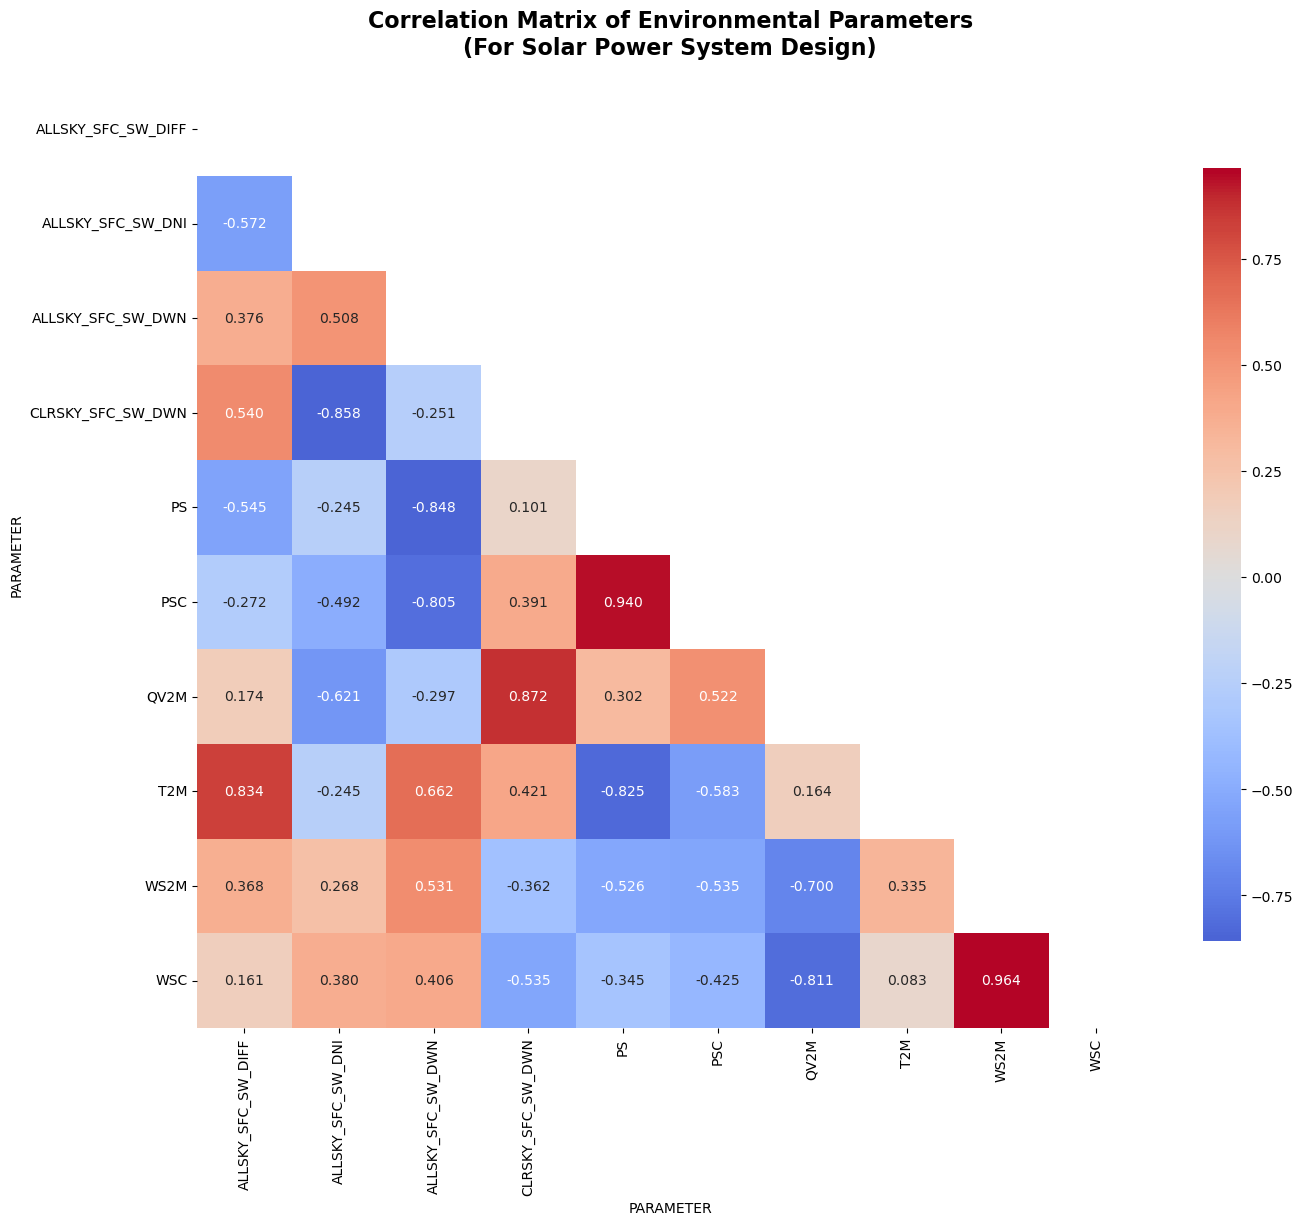


Strong Correlations (|r| > 0.7):
ALLSKY_SFC_SW_DIFF vs T2M: 0.834
ALLSKY_SFC_SW_DNI vs CLRSKY_SFC_SW_DWN: -0.858
ALLSKY_SFC_SW_DWN vs PS: -0.848
ALLSKY_SFC_SW_DWN vs PSC: -0.805
CLRSKY_SFC_SW_DWN vs QV2M: 0.872
PS vs PSC: 0.940
PS vs T2M: -0.825
QV2M vs WS2M: -0.700
QV2M vs WSC: -0.811
WS2M vs WSC: 0.964


In [7]:
print("CORRELATION ANALYSIS")
print("="*50)

plt.figure(figsize=(14, 12))
correlation_matrix = df_processed.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
plt.title('Correlation Matrix of Environmental Parameters\n(For Solar Power System Design)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Display strong correlations
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            strong_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

print("\nStrong Correlations (|r| > 0.7):")
for corr in strong_corr:
    print(f"{corr[0]} vs {corr[1]}: {corr[2]:.3f}")


## SCATTER PLOTS WITH TRENDS LINES

SCATTER PLOT ANALYSIS WITH TREND LINES


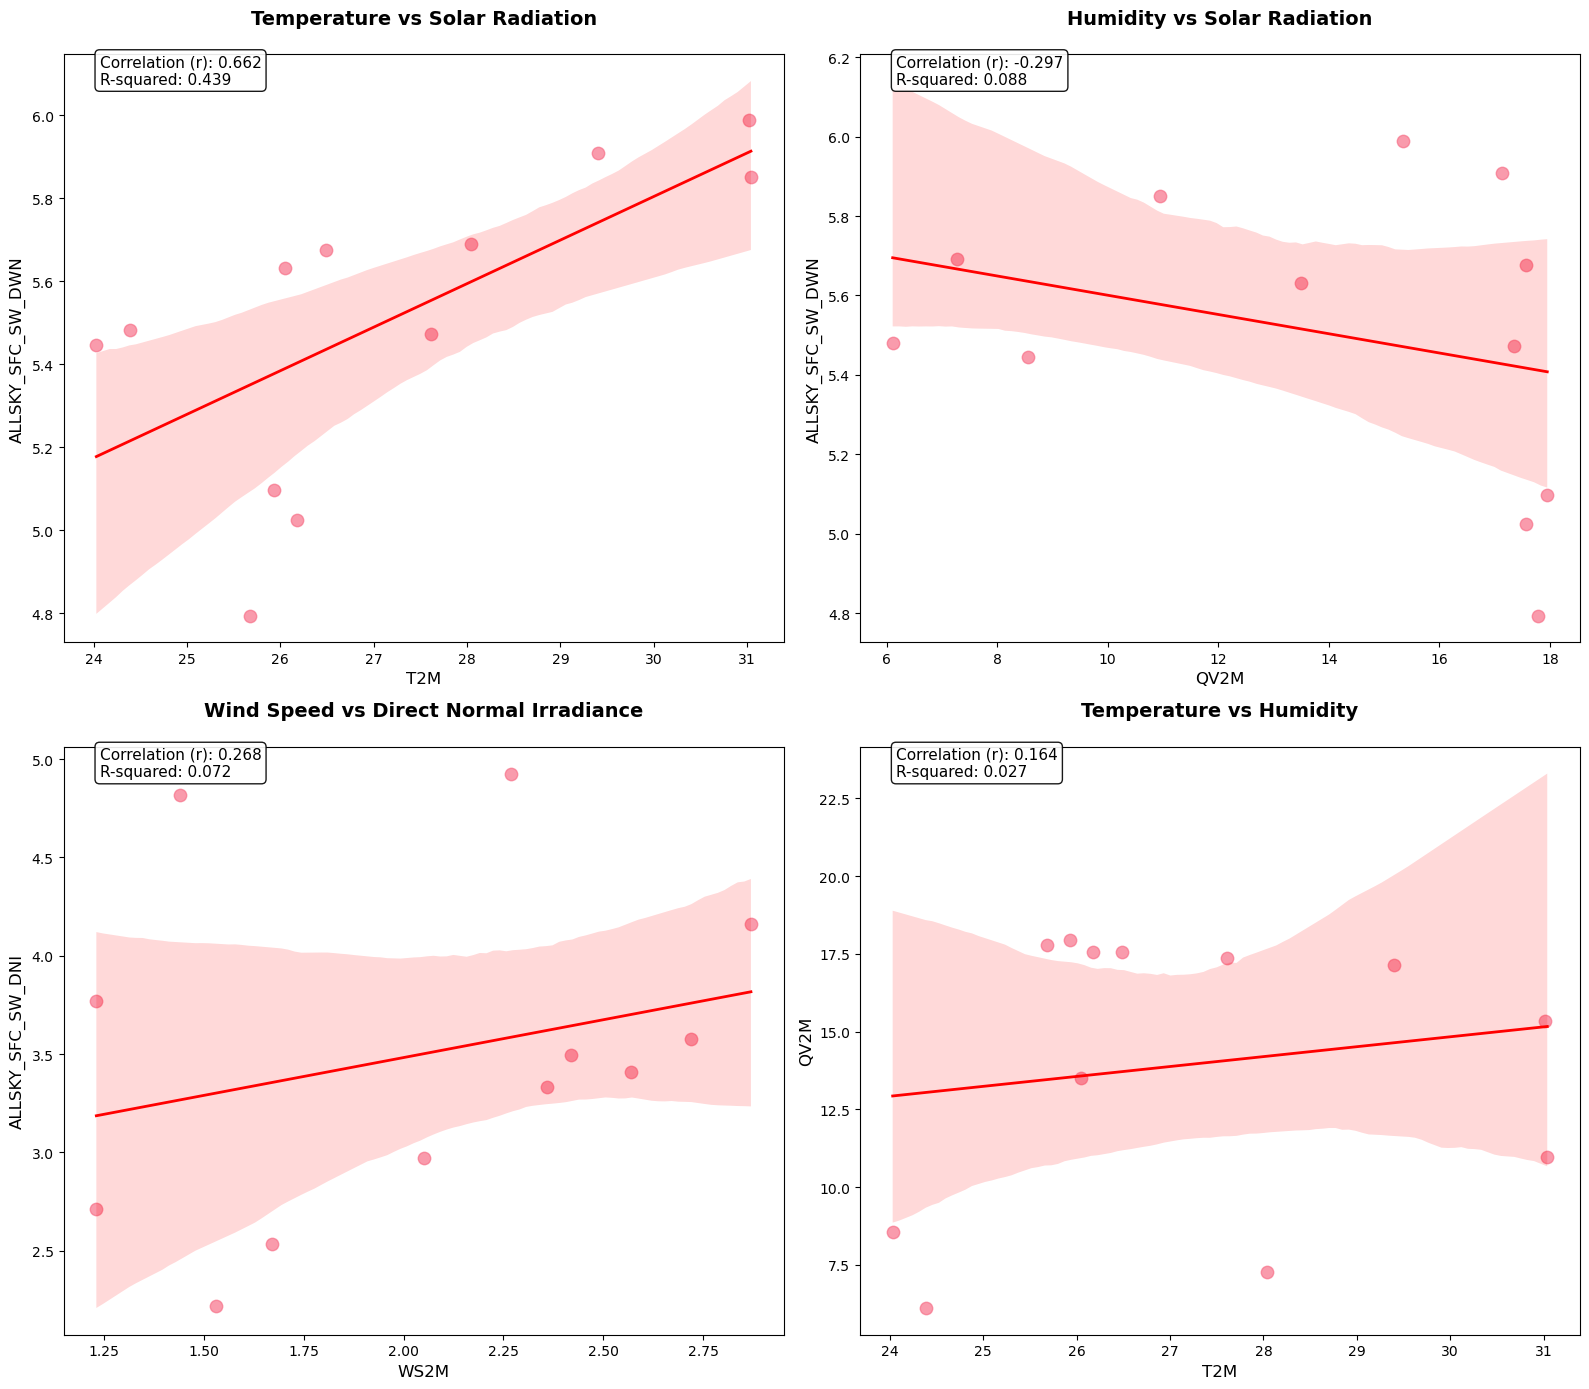

In [8]:
print("SCATTER PLOT ANALYSIS WITH TREND LINES")
print("="*50)

# Select key relationships for solar power
relationships = [
    ('T2M', 'ALLSKY_SFC_SW_DWN', 'Temperature vs Solar Radiation'),
    ('QV2M', 'ALLSKY_SFC_SW_DWN', 'Humidity vs Solar Radiation'),
    ('WS2M', 'ALLSKY_SFC_SW_DNI', 'Wind Speed vs Direct Normal Irradiance'),
    ('T2M', 'QV2M', 'Temperature vs Humidity')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (x_var, y_var, title) in enumerate(relationships):
    sns.regplot(data=df_processed, x=x_var, y=y_var, ax=axes[idx], 
                scatter_kws={'alpha':0.7, 's':80}, 
                line_kws={'color': 'red', 'linewidth':2},
                ci=95)
    axes[idx].set_title(f'{title}\n', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(x_var, fontsize=12)
    axes[idx].set_ylabel(y_var, fontsize=12)
    
    # Calculate correlation and R-squared
    corr = df_processed[x_var].corr(df_processed[y_var])
    r_squared = corr ** 2
    axes[idx].text(0.05, 0.95, f'Correlation (r): {corr:.3f}\nR-squared: {r_squared:.3f}', 
                   transform=axes[idx].transAxes, fontsize=11,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()


## MONTHLY TREND ANALYSIS

MONTHLY TREND ANALYSIS


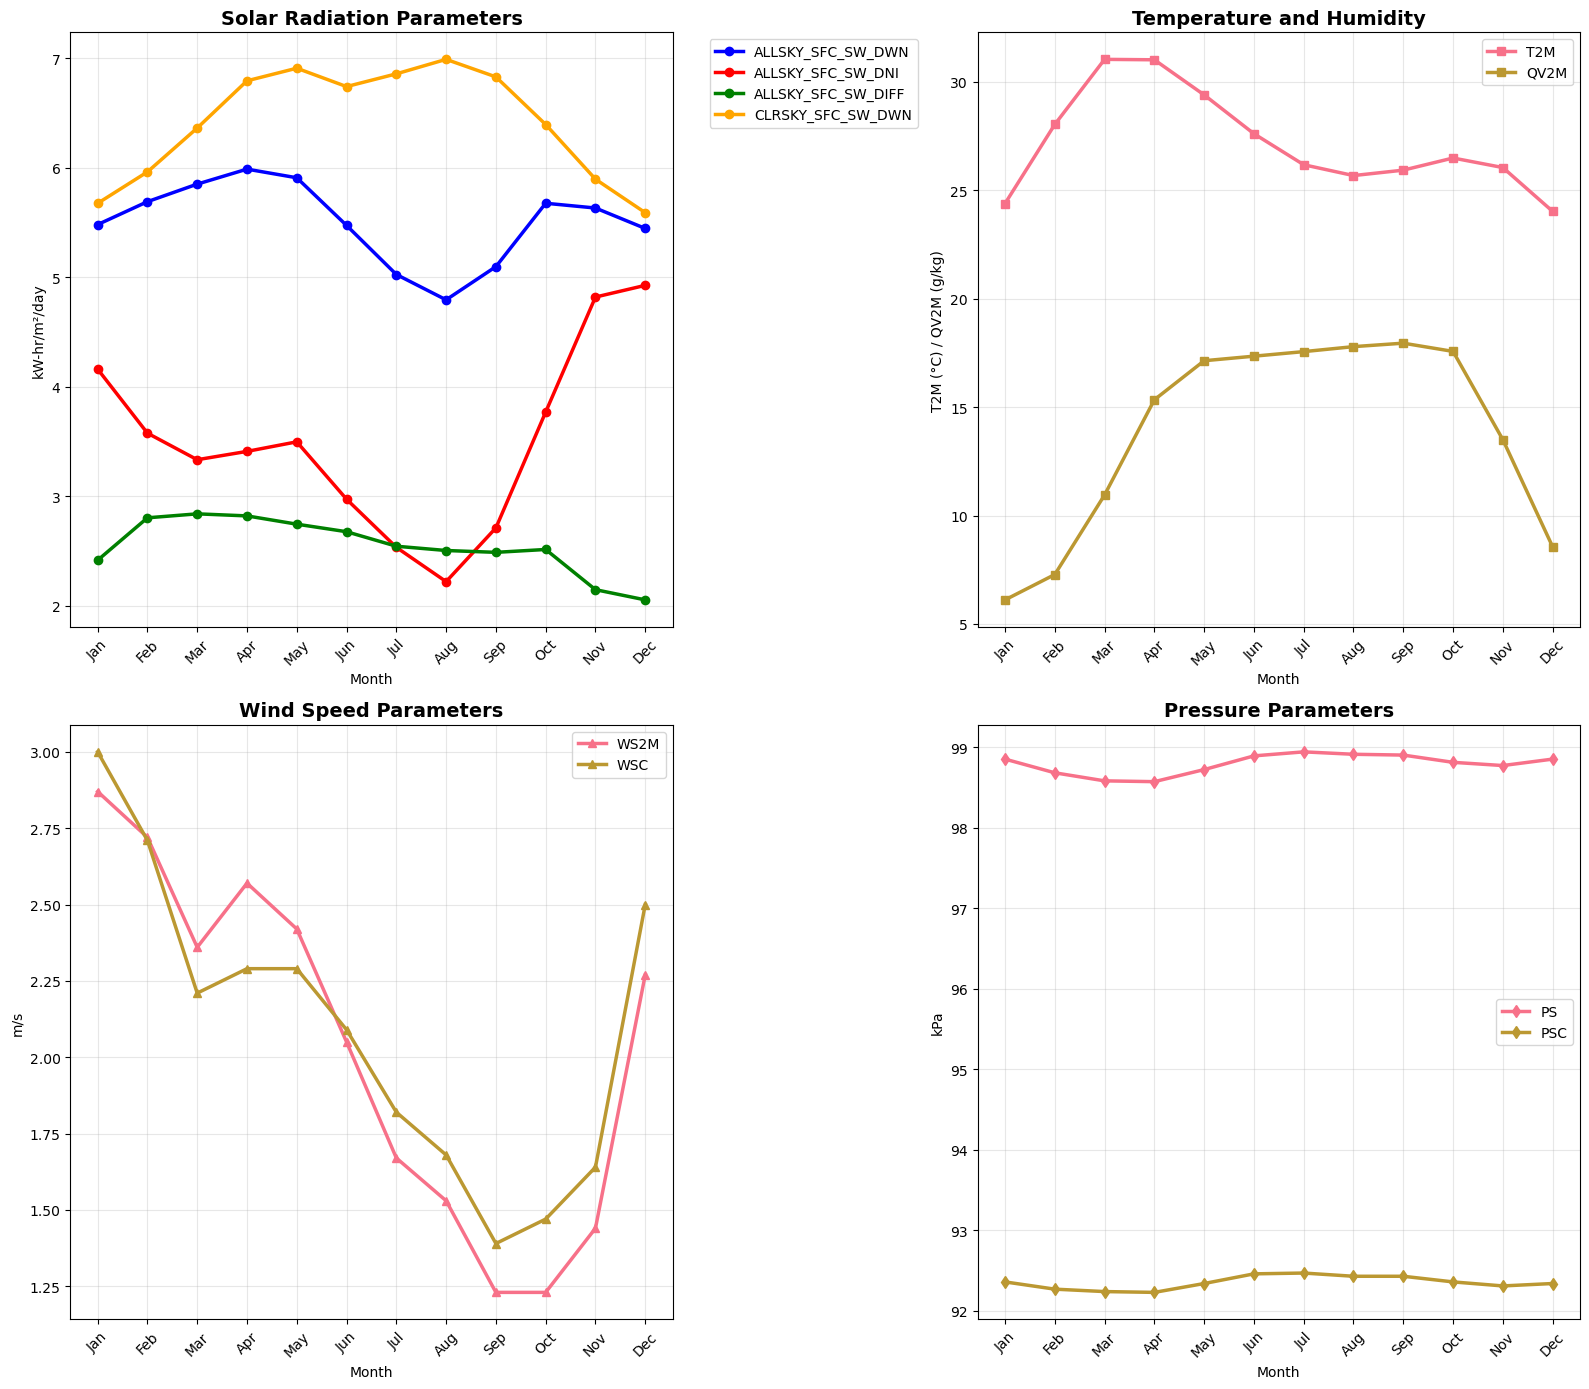

In [9]:
print("MONTHLY TREND ANALYSIS")
print("="*50)

# Create month names for better x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Solar radiation parameters
solar_vars = ['ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF', 'CLRSKY_SFC_SW_DWN']
colors = ['blue', 'red', 'green', 'orange']
for i, var in enumerate(solar_vars):
    axes[0,0].plot(df_processed.index, df_processed[var], marker='o', linewidth=2.5, 
                   label=var, color=colors[i], markersize=6)
axes[0,0].set_title('Solar Radiation Parameters', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('kW-hr/m²/day')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].set_xticklabels(month_names, rotation=45)
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# Environmental parameters
env_vars = ['T2M', 'QV2M']
for var in env_vars:
    axes[0,1].plot(df_processed.index, df_processed[var], marker='s', linewidth=2.5, 
                   label=var, markersize=6)
axes[0,1].set_title('Temperature and Humidity', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('T2M (°C) / QV2M (g/kg)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_names, rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Wind parameters
wind_vars = ['WS2M', 'WSC']
for var in wind_vars:
    axes[1,0].plot(df_processed.index, df_processed[var], marker='^', linewidth=2.5, 
                   label=var, markersize=6)
axes[1,0].set_title('Wind Speed Parameters', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('m/s')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(month_names, rotation=45)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Pressure parameters
pressure_vars = ['PS', 'PSC']
for var in pressure_vars:
    axes[1,1].plot(df_processed.index, df_processed[var], marker='d', linewidth=2.5, 
                   label=var, markersize=6)
axes[1,1].set_title('Pressure Parameters', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('kPa')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(month_names, rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3D SURFACE PLOT

3D SURFACE PLOT ANALYSIS


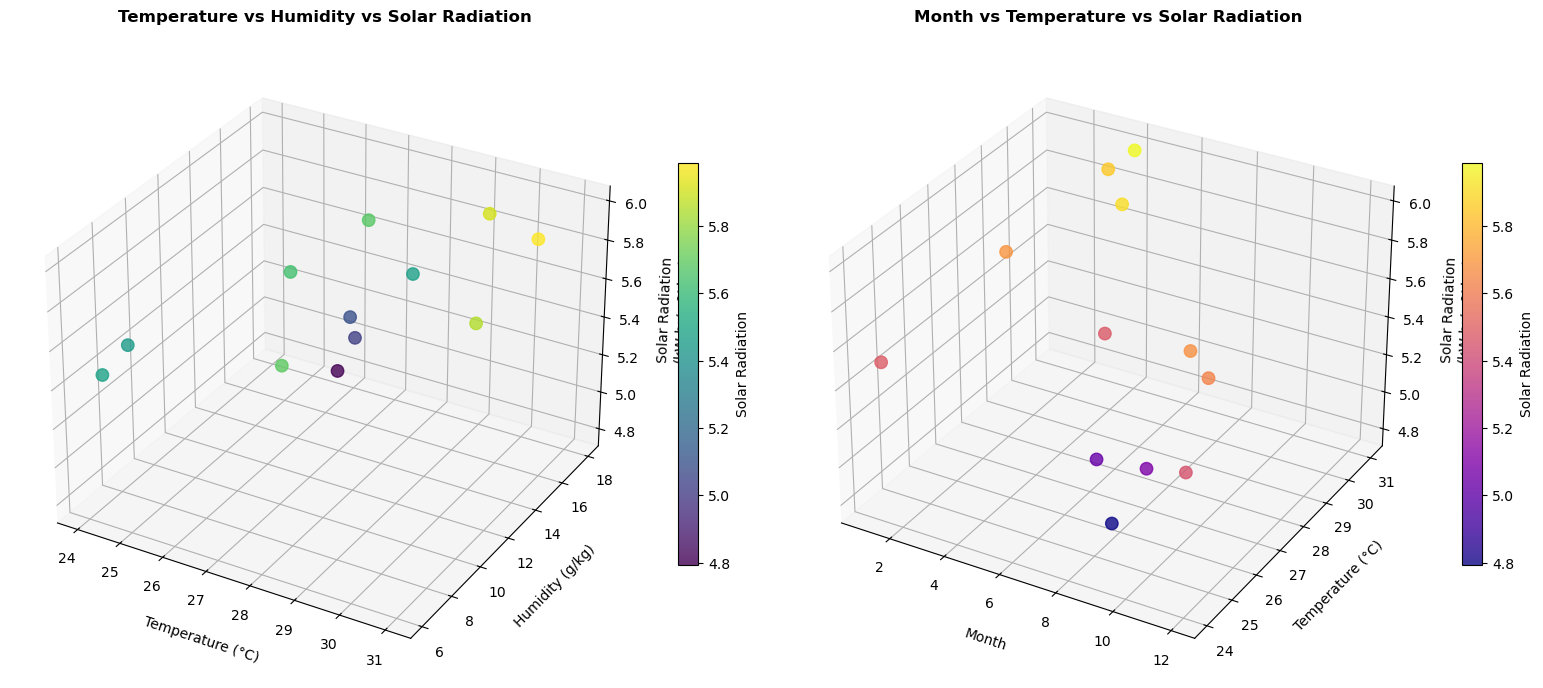

In [10]:
print("3D SURFACE PLOT ANALYSIS")
print("="*50)

fig = plt.figure(figsize=(16, 7))

# 3D plot: Temperature vs Humidity vs Solar Radiation
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(df_processed['T2M'], df_processed['QV2M'], df_processed['ALLSKY_SFC_SW_DWN'], 
                     c=df_processed['ALLSKY_SFC_SW_DWN'], cmap='viridis', s=80, alpha=0.8)
ax1.set_xlabel('Temperature (°C)', fontsize=10, labelpad=10)
ax1.set_ylabel('Humidity (g/kg)', fontsize=10, labelpad=10)
ax1.set_zlabel('Solar Radiation\n(kW-hr/m²/day)', fontsize=10, labelpad=10)
ax1.set_title('Temperature vs Humidity vs Solar Radiation', fontsize=12, fontweight='bold', pad=20)
plt.colorbar(scatter, ax=ax1, shrink=0.6, label='Solar Radiation')

# 3D plot: Month vs Temperature vs Solar Radiation
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(df_processed.index, df_processed['T2M'], df_processed['ALLSKY_SFC_SW_DWN'], 
                      c=df_processed['ALLSKY_SFC_SW_DWN'], cmap='plasma', s=80, alpha=0.8)
ax2.set_xlabel('Month', fontsize=10, labelpad=10)
ax2.set_ylabel('Temperature (°C)', fontsize=10, labelpad=10)
ax2.set_zlabel('Solar Radiation\n(kW-hr/m²/day)', fontsize=10, labelpad=10)
ax2.set_title('Month vs Temperature vs Solar Radiation', fontsize=12, fontweight='bold', pad=20)
plt.colorbar(scatter2, ax=ax2, shrink=0.6, label='Solar Radiation')

plt.tight_layout()
plt.show()


## SOLAR POWER POTENTIAL ANALYSIS

SOLAR POWER POTENTIAL ANALYSIS


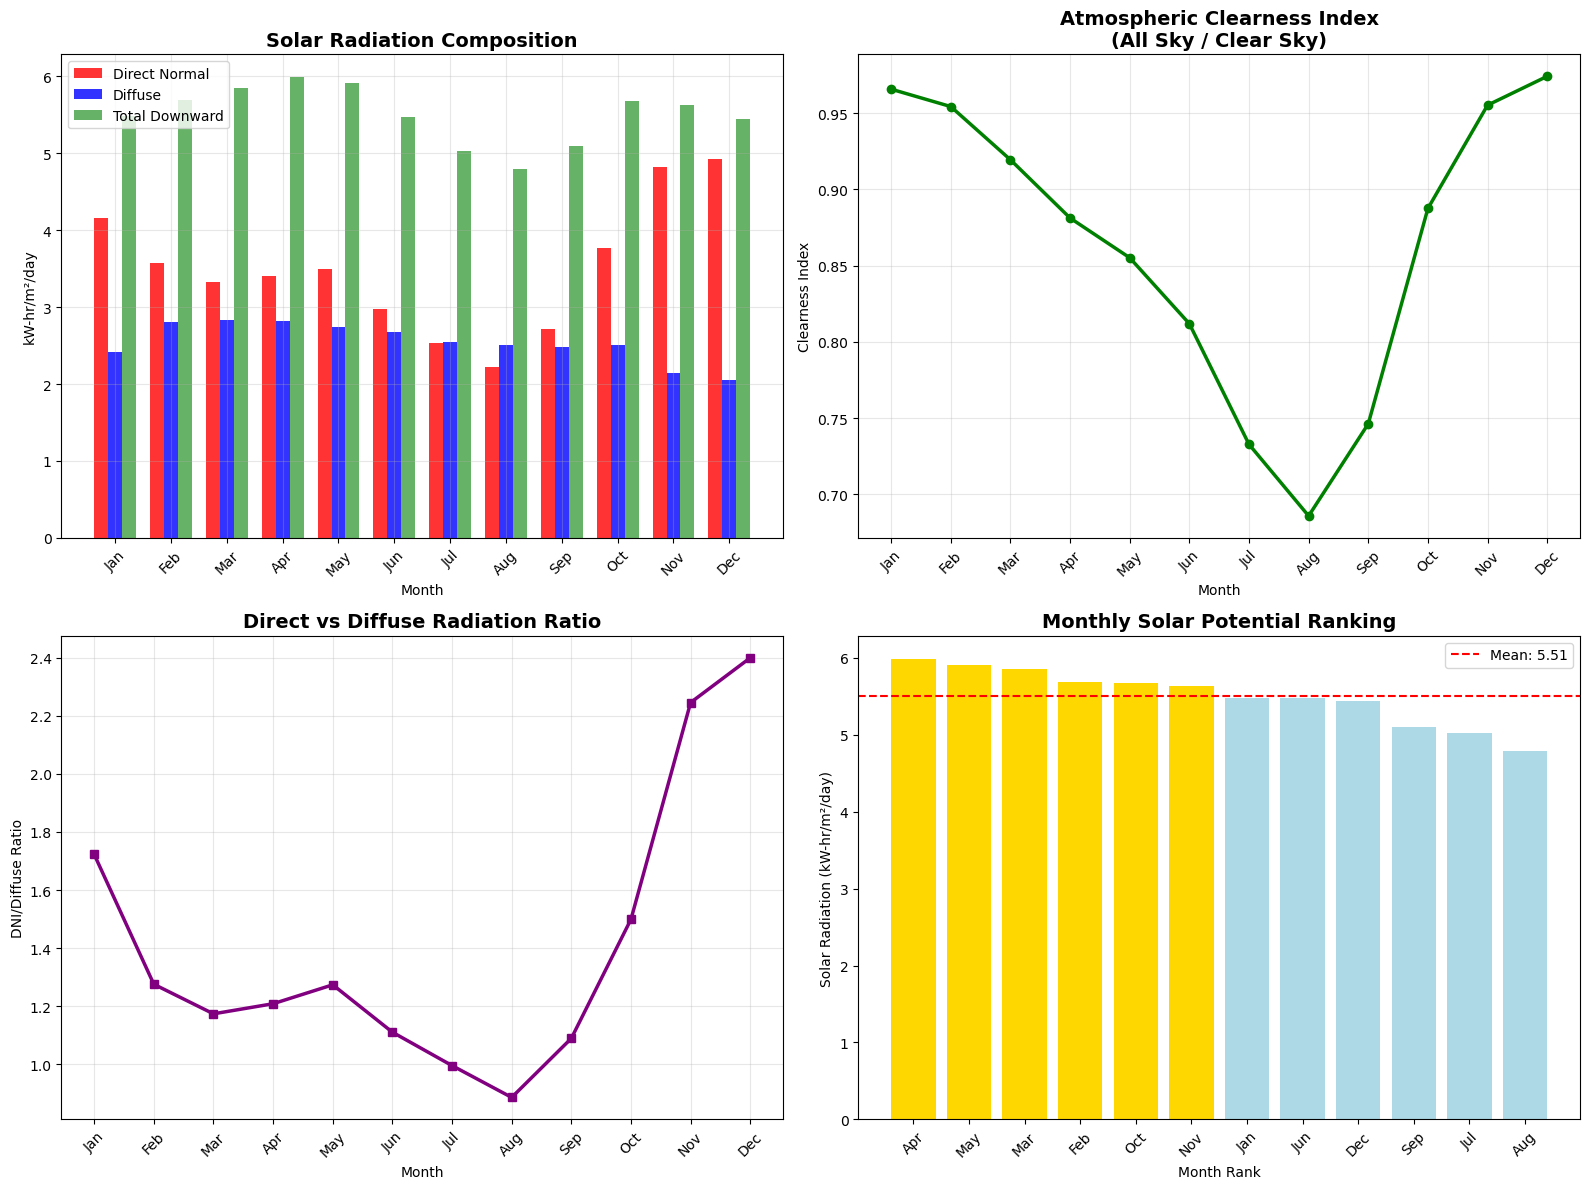

In [11]:
print("SOLAR POWER POTENTIAL ANALYSIS")
print("="*50)

# Calculate solar potential metrics
solar_potential = df_processed[['ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF']].copy()
solar_potential['Clearness_Index'] = df_processed['ALLSKY_SFC_SW_DWN'] / df_processed['CLRSKY_SFC_SW_DWN']
solar_potential['DNI_Diffuse_Ratio'] = df_processed['ALLSKY_SFC_SW_DNI'] / df_processed['ALLSKY_SFC_SW_DIFF']

plt.figure(figsize=(16, 12))

# Solar radiation composition
plt.subplot(2, 2, 1)
months = range(1, 13)
bar_width = 0.25
plt.bar([x - bar_width for x in months], df_processed['ALLSKY_SFC_SW_DNI'], width=bar_width, 
        label='Direct Normal', alpha=0.8, color='red')
plt.bar(months, df_processed['ALLSKY_SFC_SW_DIFF'], width=bar_width, 
        label='Diffuse', alpha=0.8, color='blue')
plt.bar([x + bar_width for x in months], df_processed['ALLSKY_SFC_SW_DWN'], width=bar_width, 
        label='Total Downward', alpha=0.6, color='green')
plt.xlabel('Month')
plt.ylabel('kW-hr/m²/day')
plt.title('Solar Radiation Composition', fontsize=14, fontweight='bold')
plt.xticks(months, month_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Clearness index
plt.subplot(2, 2, 2)
plt.plot(months, solar_potential['Clearness_Index'], marker='o', linewidth=2.5, color='green', markersize=6)
plt.xlabel('Month')
plt.ylabel('Clearness Index')
plt.title('Atmospheric Clearness Index\n(All Sky / Clear Sky)', fontsize=14, fontweight='bold')
plt.xticks(months, month_names, rotation=45)
plt.grid(True, alpha=0.3)

# DNI to Diffuse ratio
plt.subplot(2, 2, 3)
plt.plot(months, solar_potential['DNI_Diffuse_Ratio'], marker='s', linewidth=2.5, color='purple', markersize=6)
plt.xlabel('Month')
plt.ylabel('DNI/Diffuse Ratio')
plt.title('Direct vs Diffuse Radiation Ratio', fontsize=14, fontweight='bold')
plt.xticks(months, month_names, rotation=45)
plt.grid(True, alpha=0.3)

# Optimal months for solar power
plt.subplot(2, 2, 4)
optimal_months = df_processed['ALLSKY_SFC_SW_DWN'].sort_values(ascending=False)
colors = ['gold' if x > df_processed['ALLSKY_SFC_SW_DWN'].mean() else 'lightblue' for x in optimal_months]
plt.bar(range(len(optimal_months)), optimal_months.values, color=colors)
plt.axhline(y=df_processed['ALLSKY_SFC_SW_DWN'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df_processed["ALLSKY_SFC_SW_DWN"].mean():.2f}')
plt.xlabel('Month Rank')
plt.ylabel('Solar Radiation (kW-hr/m²/day)')
plt.title('Monthly Solar Potential Ranking', fontsize=14, fontweight='bold')
plt.xticks(range(12), [month_names[i-1] for i in optimal_months.index], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


## HEATMAP WITH CLUSTERING

HEATMAP WITH CLUSTERING ANALYSIS


<Figure size 1400x1000 with 0 Axes>

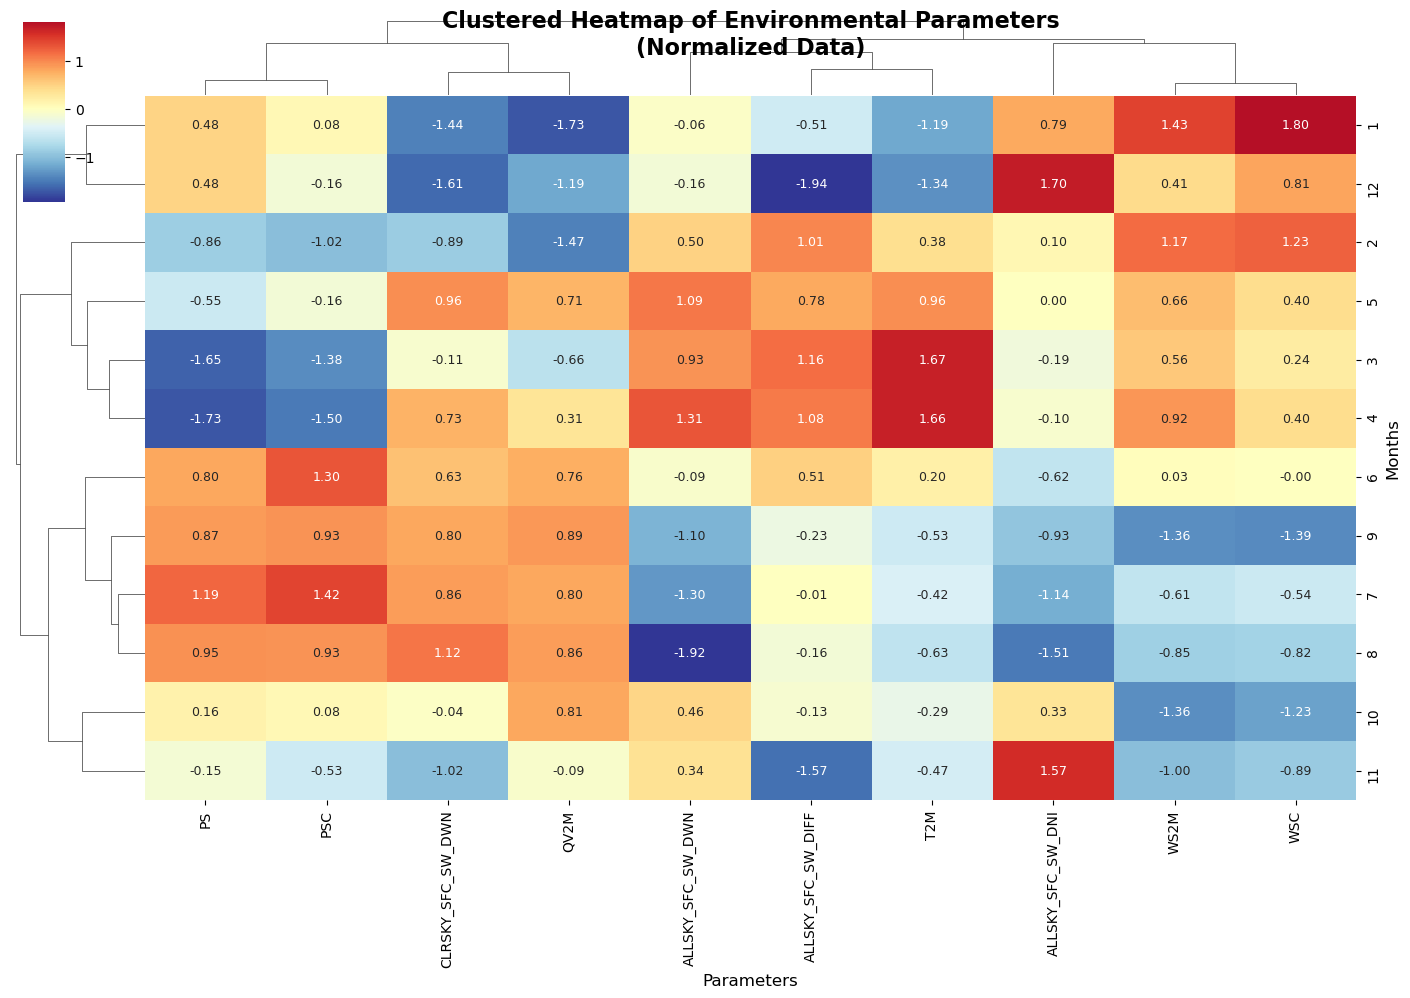

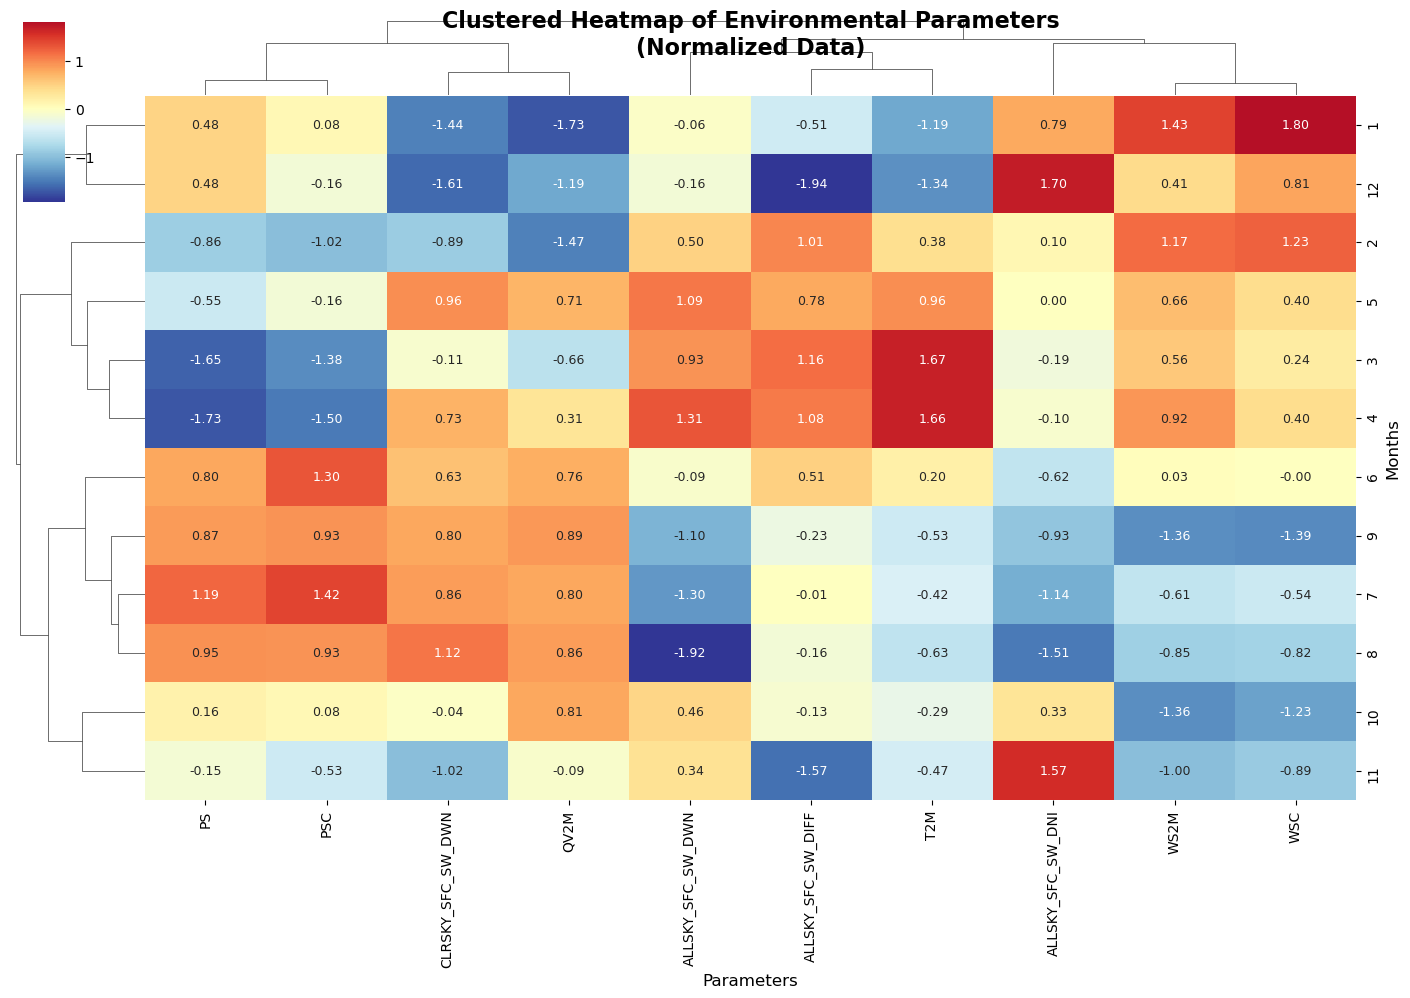

In [12]:
print("HEATMAP WITH CLUSTERING ANALYSIS")
print("="*50)

plt.figure(figsize=(14, 10))

# Normalize data for better clustering visualization
normalized_data = (df_processed - df_processed.mean()) / df_processed.std()

# Create clustered heatmap
clustered_heatmap = sns.clustermap(normalized_data, 
                                   cmap='RdYlBu_r', 
                                   center=0,
                                   annot=True, 
                                   fmt='.2f',
                                   figsize=(14, 10),
                                   dendrogram_ratio=0.1,
                                   cbar_pos=(0.02, 0.8, 0.03, 0.18),
                                   annot_kws={'size': 9})
clustered_heatmap.ax_heatmap.set_title('Clustered Heatmap of Environmental Parameters\n(Normalized Data)', 
                                      fontsize=16, fontweight='bold', pad=30)
clustered_heatmap.ax_heatmap.set_xlabel('Parameters', fontsize=12)
clustered_heatmap.ax_heatmap.set_ylabel('Months', fontsize=12)

plt.show()


## kEY INSIGHTS

In [13]:
print("KEY INSIGHTS FOR SOLAR POWER SYSTEM DESIGN")
print("="*50)

# Best months for solar power
best_months = df_processed['ALLSKY_SFC_SW_DWN'].nlargest(3)
worst_months = df_processed['ALLSKY_SFC_SW_DWN'].nsmallest(3)

month_names_dict = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

print(f"\nSOLAR RADIATION ANALYSIS:")
print(f"   • Average Daily Solar Radiation: {df_processed['ALLSKY_SFC_SW_DWN'].mean():.2f} kW-hr/m²/day")
print(f"   • Best Months for Solar Power: {[month_names_dict[m] for m in best_months.index]}")
print(f"   • Worst Months for Solar Power: {[month_names_dict[m] for m in worst_months.index]}")
print(f"   • Seasonal Variation: {(df_processed['ALLSKY_SFC_SW_DWN'].max() - df_processed['ALLSKY_SFC_SW_DWN'].min()):.2f} kW-hr/m²/day")

print(f"\n ENVIRONMENTAL FACTORS:")
print(f"   • Average Temperature: {df_processed['T2M'].mean():.1f}°C")
print(f"   • Average Humidity: {df_processed['QV2M'].mean():.1f} g/kg")
print(f"   • Average Wind Speed: {df_processed['WS2M'].mean():.2f} m/s")

print(f"\n DESIGN RECOMMENDATIONS:")
print("   1.  System Sizing: Consider 20-30% oversizing to account for seasonal variation")
print("   2.  Cooling Requirements: Implement passive cooling for temperature management")
print("   3.  Maintenance: Schedule cleaning before high-humidity periods")
print("   4.  Structural Design: Ensure mounting systems can withstand maximum wind speeds")
print("   5.  Energy Storage: Size batteries to cover low-production months")

# Calculate performance metrics
performance_metrics = {
    'Annual_Solar_Potential (kW-hr/m²)': df_processed['ALLSKY_SFC_SW_DWN'].sum() * 30.44,
    'Seasonality_Factor': df_processed['ALLSKY_SFC_SW_DWN'].std() / df_processed['ALLSKY_SFC_SW_DWN'].mean(),
    'Direct_Radiation_Ratio': df_processed['ALLSKY_SFC_SW_DNI'].mean() / df_processed['ALLSKY_SFC_SW_DWN'].mean(),
    'System_Efficiency_Impact': (df_processed['T2M'].max() - 25) * -0.0045  # Typical temperature coefficient
}

print(f"\n PERFORMANCE METRICS:")
for metric, value in performance_metrics.items():
    print(f"   • {metric}: {value:.3f}")


KEY INSIGHTS FOR SOLAR POWER SYSTEM DESIGN

SOLAR RADIATION ANALYSIS:
   • Average Daily Solar Radiation: 5.51 kW-hr/m²/day
   • Best Months for Solar Power: ['Apr', 'May', 'Mar']
   • Worst Months for Solar Power: ['Aug', 'Jul', 'Sep']
   • Seasonal Variation: 1.19 kW-hr/m²/day

 ENVIRONMENTAL FACTORS:
   • Average Temperature: 27.2°C
   • Average Humidity: 13.9 g/kg
   • Average Wind Speed: 2.03 m/s

 DESIGN RECOMMENDATIONS:
   1.  System Sizing: Consider 20-30% oversizing to account for seasonal variation
   2.  Cooling Requirements: Implement passive cooling for temperature management
   3.  Maintenance: Schedule cleaning before high-humidity periods
   4.  Structural Design: Ensure mounting systems can withstand maximum wind speeds
   5.  Energy Storage: Size batteries to cover low-production months

 PERFORMANCE METRICS:
   • Annual_Solar_Potential (kW-hr/m²): 2011.016
   • Seasonality_Factor: 0.067
   • Direct_Radiation_Ratio: 0.635
   • System_Efficiency_Impact: -0.027
